# 05. Clustered Experiments

Many real experiments cannot randomize individual users independently. A delivery marketplace might randomize cities, a retail chain might randomize stores, a sales platform might randomize account teams, and a hospital system might randomize clinics. In each case, the treatment is assigned to a **cluster** of units.

Clustered experiments are powerful because they let us test interventions that are operationally, socially, or technically delivered at a group level. They are dangerous because the data can look much larger than the experiment really is. Ten thousand users nested inside 40 stores differ from ten thousand independently randomized users.

The central idea of this notebook is:

> In a clustered experiment, the number of independent randomization units is closer to the number of clusters than the number of rows in the dataset.

Individual-level data remain useful. They help define metrics, adjust for pre-treatment covariates, diagnose heterogeneity, and improve precision. The design and inference still need to respect the cluster randomization.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why teams randomize stores, schools, clinics, sellers, markets, accounts, or regions instead of individual users.
- Distinguish the unit of randomization, unit of observation, unit of analysis, and target estimand.
- Define intracluster correlation and explain why it reduces effective sample size.
- Compute and interpret the cluster design effect.
- Compare naive user-level inference with cluster-aware inference.
- Show why adding more users inside the same clusters has diminishing returns.
- Diagnose problems caused by few clusters and unequal cluster sizes.
- Decide when to use cluster-level aggregation, cluster-robust standard errors, blocking, or pair matching.
- Write an industry-facing experiment plan for a clustered rollout.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "assignment": "#d7ecff",
    "cluster": "#ffe0c2",
    "individual": "#dff0d8",
    "outcome": "#eadcf8",
    "warning": "#fff1c7",
    "decision": "#ffd6db",
    "neutral": "#f7f7f7",
    "analysis": "#e1f3ef",
}

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.70")
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2b2b2b",
        fontname="Helvetica",
        fontsize="11",
        margin="0.12,0.08",
    )
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            dot.edge(src, dst)
        elif len(edge) == 3:
            src, dst, label = edge
            dot.edge(src, dst, label=label)
    return dot


def design_effect(avg_cluster_size, icc):
    """
    Compute the variance inflation caused by clustering under equal cluster sizes.
    
    Idea:
        Clustered experiments have less independent information than individual randomization because units in the same cluster move together.
    
    Args:
        avg_cluster_size: Average number of observations per randomized cluster.
        icc: Intracluster correlation assumed or estimated for clustered outcomes.
    
    Returns:
        float: Design-effect multiplier applied to individual-level variance calculations.
    """
    return 1 + (avg_cluster_size - 1) * icc


def effective_sample_size(n_units, avg_cluster_size, icc):
    """Compute Kish effective sample size from a vector of weights.

    Args:
        n_units: Number of individual units represented by the design.
        avg_cluster_size: Average number of units per cluster.
        icc: Intracluster correlation used in a clustered experiment calculation.

    Returns:
        float: Effective sample size implied by the design or weights.
    """
    return n_units / design_effect(avg_cluster_size, icc)


def estimate_icc_anova(df, cluster_col, y_col):
    """
    Estimate intracluster correlation using a one-way ANOVA decomposition.
    
    Idea:
        The ICC measures how much outcome variation sits between clusters rather than within clusters, which drives clustered-experiment power.
    
    Args:
        df: DataFrame containing the treatment, outcome, cluster, or covariate columns needed by the helper.
        cluster_col: Column identifying the randomized or naturally clustered unit.
        y_col: Outcome column used to estimate between- and within-cluster variance.
    
    Returns:
        float: Estimated intracluster correlation clipped to a feasible nonnegative value.
    """
    grouped = df.groupby(cluster_col)[y_col]
    sizes = grouped.size()
    means = grouped.mean()
    grand_mean = df[y_col].mean()
    k = sizes.shape[0]
    n = sizes.sum()
    ss_between = (sizes * (means - grand_mean) ** 2).sum()
    ss_within = grouped.apply(lambda x: ((x - x.mean()) ** 2).sum()).sum()
    ms_between = ss_between / (k - 1)
    ms_within = ss_within / (n - k)
    n_bar = (n - (sizes.pow(2).sum() / n)) / (k - 1)
    return (ms_between - ms_within) / (ms_between + (n_bar - 1) * ms_within)


def plot_ci_table(table, title, xlabel, reference=None, figsize=(8.5, 4.0)):
    """Plot estimates with confidence intervals against an optional reference value.

    Args:
        table: Summary table containing estimates, intervals, or diagnostics.
        title: Title shown on the resulting figure.
        xlabel: X-axis label for the resulting figure.
        reference: Reference value or omitted event time used for interpretation.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes containing confidence intervals.
    """
    ordered = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(ordered))
    ax.errorbar(
        ordered["estimate"],
        y,
        xerr=[ordered["estimate"] - ordered["ci_low"], ordered["ci_high"] - ordered["estimate"]],
        fmt="o",
        color="#2f6f9f",
        ecolor="#2f6f9f",
        elinewidth=2,
        capsize=4,
    )
    if reference is not None:
        ax.axvline(reference, color="#b23b3b", linestyle="--", linewidth=2, label="True effect")
        ax.legend(loc="lower right")
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(ordered["method"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 1. What Is a Clustered Experiment?

A clustered experiment randomizes groups of units rather than individual units. The cluster may be a store, market, classroom, clinic, village, team, seller, employer, account, region, warehouse, or device fleet.

| Concept | Meaning | Example |
|---|---|---|
| Unit of randomization | The unit assigned to treatment or control | Store |
| Unit of observation | The row level in the analysis dataset | Customer visit |
| Unit of treatment delivery | Where the intervention is implemented | Store-level staffing policy |
| Unit of decision | The business level where the decision is made | Roll out policy to all stores |
| Target estimand | The causal effect the team wants to learn | Average effect per customer visit or per store |

The hard part is that these units are not always the same. If stores are randomized but customer visits are rows, the rows inside one store share the same assignment and often share unobserved store-level factors. This creates dependence inside clusters.

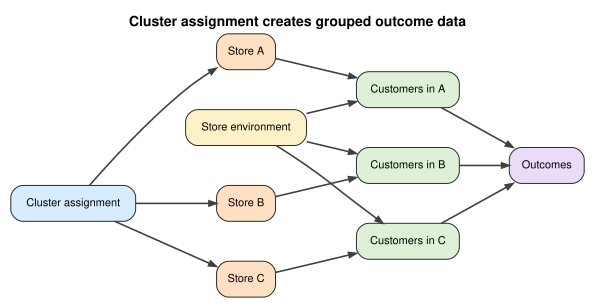

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
cluster_edges = [
    ("Cluster assignment", "Store A"),
    ("Cluster assignment", "Store B"),
    ("Cluster assignment", "Store C"),
    ("Store A", "Customers in A"),
    ("Store B", "Customers in B"),
    ("Store C", "Customers in C"),
    ("Store environment", "Customers in A"),
    ("Store environment", "Customers in B"),
    ("Store environment", "Customers in C"),
    ("Customers in A", "Outcomes"),
    ("Customers in B", "Outcomes"),
    ("Customers in C", "Outcomes"),
]
cluster_colors = {
    "Cluster assignment": COLORS["assignment"],
    "Store A": COLORS["cluster"],
    "Store B": COLORS["cluster"],
    "Store C": COLORS["cluster"],
    "Store environment": COLORS["warning"],
    "Customers in A": COLORS["individual"],
    "Customers in B": COLORS["individual"],
    "Customers in C": COLORS["individual"],
    "Outcomes": COLORS["outcome"],
}

smart_display(make_dag(cluster_edges, "Cluster assignment creates grouped outcome data", cluster_colors))

The experiment has many customer rows, but treatment assignment varies only at the store level. Customers in the same store are exposed to the same treatment status and the same store environment. If we analyze each customer row as if it were independently randomized, we usually make the uncertainty look too small.

## 2. Why Randomize Clusters?

Cluster randomization is not a statistical luxury. In industry settings, it is often the only credible design.

Common reasons include:

| Reason | Industry example | Why individual randomization is hard |
|---|---|---|
| Contamination | Sales representatives use a new playbook | One representative cannot use two playbooks with different customers cleanly |
| Operational delivery | Store layout, training, staffing, routing | The treatment is implemented at the store or site level |
| Spillovers | Marketplace incentives, search ranking, pricing | One user's treatment can change another user's experience |
| Compliance | Account manager workflow, clinical protocol | Individual-level assignment may be ignored or impossible |
| Fairness and communication | School, workplace, regional policy | Mixed treatment inside a visible group may be unacceptable |
| Infrastructure | Cache policy, warehouse process, fraud-review queue | Systems may switch at the queue, market, or fleet level |

Cluster-randomized trials are common when interventions are delivered to groups, but the design requires explicit attention to within-cluster correlation and the number of available clusters (Campbell et al., 2004; Kennedy-Shaffer & Hughes, 2021). Imai, King, and Nall (2009) use examples such as households, communities, firms, medical practices, schools, and classrooms to describe this basic design feature.

## 3. Intracluster Correlation

The **intracluster correlation coefficient**, usually written as $
ho$, measures how similar units are inside the same cluster.

One simple variance-components model is:

$$
Y_{ij} = \mu + u_j + \epsilon_{ij},
$$

where $i$ indexes individuals and $j$ indexes clusters. The cluster effect is $u_j$ and the individual-level noise is $\epsilon_{ij}$. If:

$$
u_j \sim (0, \sigma_u^2), \qquad \epsilon_{ij} \sim (0, \sigma_\epsilon^2),
$$

then the intracluster correlation is:

$$
\rho = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_\epsilon^2}.
$$

When $\rho = 0$, observations in the same cluster are no more similar than observations in different clusters. When $\rho$ is positive, each additional user inside an existing cluster provides less new information than a user from a new cluster. Campbell et al. (2004) describe the same issue as non-independence of observations within clusters, and Peerawaranun et al. (2019) describe ICC as a measure of response correlation within the same cluster.

In [4]:
# Assemble the Intracluster Correlation summary table used for interpretation.
cluster_sizes = [5, 20, 50, 100, 250]
icc_values = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20]

de_rows = []
for m in cluster_sizes:
    for icc in icc_values:
        de_rows.append({
            "avg_cluster_size": m,
            "icc": icc,
            "design_effect": design_effect(m, icc),
            "effective_n_from_10000_rows": effective_sample_size(10_000, m, icc),
        })

de_table = pd.DataFrame(de_rows)
de_table.pivot(index="avg_cluster_size", columns="icc", values="design_effect").round(2)

icc,0.00,0.01,0.03,0.05,0.10,0.20
avg_cluster_size,,,,,,
5,1.0,1.04,1.12,1.20,1.4,1.8
20,1.0,1.19,1.57,1.95,2.9,4.8
50,1.0,1.49,2.47,3.45,5.9,10.8
100,1.0,1.99,3.97,5.95,10.9,20.8
250,1.0,3.49,8.47,13.45,25.9,50.8


In Intracluster Correlation, the table shows how much independent information the design really contains. With clustered data, row counts can exaggerate precision unless uncertainty follows the randomization unit.

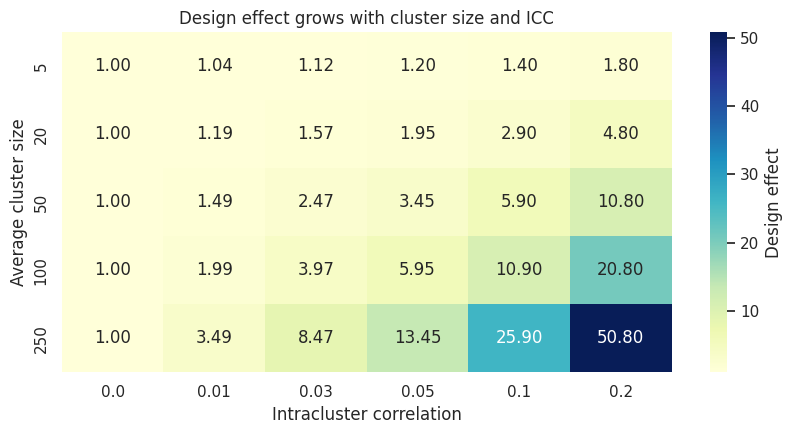

In [5]:
# Build the Intracluster Correlation plot from the quantities computed above.
heatmap_data = de_table.pivot(index="avg_cluster_size", columns="icc", values="design_effect")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Design effect"},
    ax=ax,
)
ax.set_title("Design effect grows with cluster size and ICC")
ax.set_xlabel("Intracluster correlation")
ax.set_ylabel("Average cluster size")
plt.tight_layout()
plt.show()

The equal-cluster design effect is:

$$
DE = 1 + (m - 1)\rho,
$$

where $m$ is the average cluster size. This formula appears widely in discussions of cluster-randomized trials; Campbell et al. (2004) use the same expression to describe the loss of effective sample size.

The heatmap shows why even a small ICC matters. If $m = 100$ and $\rho = 0.05$, the design effect is $5.95$. Ten thousand rows then have roughly the information content of only:

$$
\frac{10000}{5.95} \approx 1681
$$

independent observations.

The practical message is uncomfortable but useful: a clustered experiment can have many rows and still have low precision.

## 4. Simulating a Cluster-Randomized Business Experiment

Now suppose a retail company wants to test a new store-level merchandising policy. The policy is implemented by store managers, so the company randomizes stores. Customer visits are the observation rows.

The true data-generating process has:

- Store-level randomization.
- Store-level baseline differences.
- Customer-level prior demand.
- A constant treatment effect.
- Positive within-store correlation.

We will compare three analyses:

1. **Naive user-row analysis**: treats customer visits as independent.
2. **Cluster-robust regression**: keeps user rows but clusters the standard error by store.
3. **Cluster-level aggregation**: analyzes one row per store.

**Dataset and experiment setup.** The simulated experiment represents customers nested inside stores or operational sites. Randomization happens at the cluster level because the intervention changes a shared workflow, staffing rule, or local operating process. Outcomes are measured at the customer level, but customers in the same cluster are correlated because they share managers, traffic patterns, local demand, and implementation quality. This is why the experiment cannot be analyzed as if every customer were independently assigned. The simulation includes cluster size differences and intracluster correlation so the inference problem resembles an actual field experiment.

In [6]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_store_experiment(
    n_clusters=80,
    avg_cluster_size=90,
    cluster_size_cv=0.35,
    treatment_effect=1.20,
    icc=0.08,
    individual_sd=4.0,
    seed=20260428,
):
    """
    Generate store-level clustered experiment data with controllable cluster size and ICC.
    
    Idea:
        The simulation shows why store-randomized tests need cluster-aware standard errors and planning assumptions.
    
    Args:
        n_clusters: Number of clusters to generate in the simulated experiment.
        avg_cluster_size: Average number of observations per randomized cluster.
        cluster_size_cv: Coefficient of variation controlling uneven cluster sizes.
        treatment_effect: True treatment effect embedded in the simulation.
        icc: Intracluster correlation assumed or estimated for clustered outcomes.
        individual_sd: Individual-level residual standard deviation in the clustered simulation.
        seed: Random seed for reproducible simulation or bootstrap draws.
    
    Returns:
        pandas.DataFrame: Simulated customer or store observations with treatment, cluster, covariates, and outcome.
    """
    local_rng = np.random.default_rng(seed)
    cluster_ids = np.arange(n_clusters)
    sigma_cluster = np.sqrt(icc / (1 - icc)) * individual_sd

    raw_sizes = local_rng.lognormal(
        mean=np.log(avg_cluster_size) - 0.5 * cluster_size_cv**2,
        sigma=cluster_size_cv,
        size=n_clusters,
    )
    sizes = np.maximum(25, np.round(raw_sizes)).astype(int)

    treatment_clusters = local_rng.choice(cluster_ids, size=n_clusters // 2, replace=False)
    treatment = np.isin(cluster_ids, treatment_clusters).astype(int)

    store_effect = local_rng.normal(0, sigma_cluster, size=n_clusters)
    store_quality = local_rng.normal(0, 1, size=n_clusters)

    rows = []
    for cluster_id, n, z, u, quality in zip(cluster_ids, sizes, treatment, store_effect, store_quality):
        prior_demand = local_rng.normal(0, 1, size=n)
        pre_metric = 52 + 2.2 * quality + 3.0 * prior_demand + u + local_rng.normal(0, individual_sd, size=n)
        outcome = 55 + 2.2 * quality + 3.0 * prior_demand + u + treatment_effect * z + local_rng.normal(0, individual_sd, size=n)
        rows.append(pd.DataFrame({
            "cluster_id": cluster_id,
            "customer_id": np.arange(n),
            "treatment": z,
            "store_quality": quality,
            "prior_demand": prior_demand,
            "pre_metric": pre_metric,
            "outcome": outcome,
            "cluster_size": n,
        }))

    return pd.concat(rows, ignore_index=True)


df_store = simulate_store_experiment()
print(f"Customer rows: {len(df_store):,}")
print(f"Stores: {df_store['cluster_id'].nunique():,}")
print(f"Average rows per store: {df_store.groupby('cluster_id').size().mean():.1f}")
print(f"Treatment share of stores: {df_store.groupby('cluster_id')['treatment'].first().mean():.2f}")
df_store.head()

Customer rows: 6,648
Stores: 80
Average rows per store: 83.1
Treatment share of stores: 0.50


,cluster_id,customer_id,treatment,store_quality,prior_demand,pre_metric,outcome,cluster_size
0,0,0,1,0.981246,1.800923,57.454616,62.758592,48
1,0,1,1,0.981246,1.297015,59.528463,60.719544,48
2,0,2,1,0.981246,-0.554235,52.979913,53.474985,48
3,0,3,1,0.981246,0.788067,57.428419,56.169411,48
4,0,4,1,0.981246,-0.458051,59.278808,57.253801,48


In Simulating a Cluster-Randomized Business Experiment, the model output is a reminder that independent information comes from clusters. Row counts alone can make the result look more precise than the design supports.

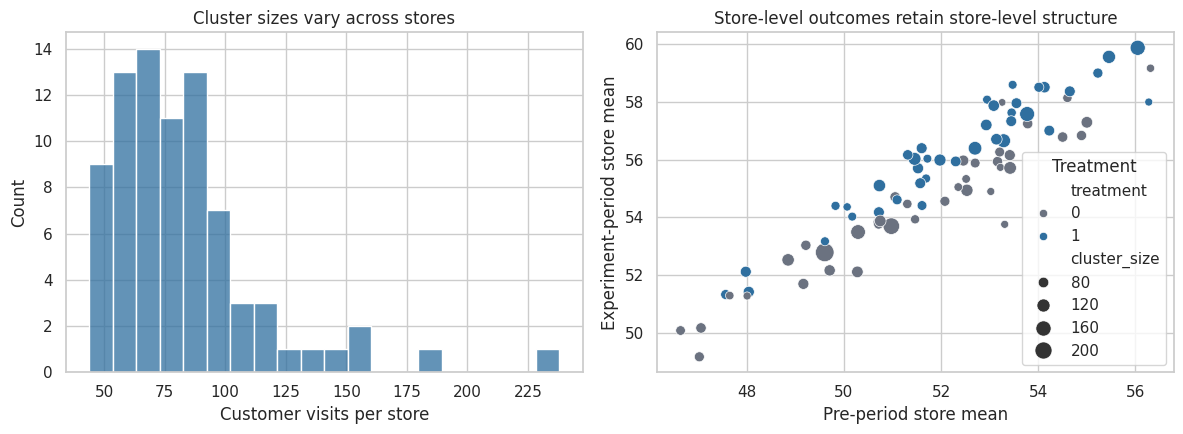

In [7]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
store_summary = (
    df_store.groupby(["cluster_id", "treatment"], as_index=False)
    .agg(
        outcome_mean=("outcome", "mean"),
        pre_metric_mean=("pre_metric", "mean"),
        cluster_size=("outcome", "size"),
        prior_demand_mean=("prior_demand", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=store_summary, x="cluster_size", bins=20, color="#2f6f9f", ax=axes[0])
axes[0].set_title("Cluster sizes vary across stores")
axes[0].set_xlabel("Customer visits per store")

sns.scatterplot(
    data=store_summary,
    x="pre_metric_mean",
    y="outcome_mean",
    hue="treatment",
    size="cluster_size",
    sizes=(30, 180),
    palette={0: "#6b7280", 1: "#2f6f9f"},
    ax=axes[1],
)
axes[1].set_title("Store-level outcomes retain store-level structure")
axes[1].set_xlabel("Pre-period store mean")
axes[1].set_ylabel("Experiment-period store mean")
axes[1].legend(title="Treatment", loc="best")
plt.tight_layout()
plt.show()

The dataset looks like a large customer-level experiment, but the scatterplot reminds us that the randomized units are stores. Each dot is one independent assignment unit. Store-level baseline differences persist into the outcome period, which is exactly why rows within a store are correlated.

In [8]:
# Assemble the Interpretation summary table used for interpretation.
control_only = df_store.query("treatment == 0")
estimated_icc = estimate_icc_anova(control_only, "cluster_id", "outcome")
avg_m = df_store.groupby("cluster_id").size().mean()
print(f"Estimated ICC among control stores: {estimated_icc:.3f}")
print(f"Average cluster size: {avg_m:.1f}")
print(f"Approximate design effect: {design_effect(avg_m, estimated_icc):.2f}")
print(f"Rows: {len(df_store):,}")
print(f"Approximate effective sample size: {effective_sample_size(len(df_store), avg_m, estimated_icc):,.0f}")

Estimated ICC among control stores: 0.149
Average cluster size: 83.1
Approximate design effect: 13.27
Rows: 6,648
Approximate effective sample size: 501


The estimated ICC will vary by simulation, but it is positive. That means a customer row inside a store is not as informative as a customer row from a new independently randomized store. The effective sample size calculation is only an approximation, especially with unequal cluster sizes, but it gives the right intuition.

## 5. Naive vs Cluster-Aware Inference

The treatment effect estimate can be similar across methods while the standard error changes substantially. This distinction is important.

Randomization protects the **point estimate** when the design is valid. Clustering mainly changes the **uncertainty** around that estimate. Cameron and Miller (2015) frame cluster-robust inference as regression inference where errors may be correlated within clusters but independent across clusters. Desai et al. (2013) similarly emphasize that ignoring clustering can distort standard errors and therefore confidence intervals and tests.

In [9]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def readout_cluster_experiment(df):
    """Estimate a clustered experiment with naive and cluster-aware uncertainty.

    Args:
        df: Analysis DataFrame used by this lecture step.

    Returns:
        pandas.DataFrame or pandas.Series: Display-ready summary for the notebook narrative.
    """
    naive_model = smf.ols("outcome ~ treatment", data=df).fit(cov_type="HC1")
    cluster_model = smf.ols("outcome ~ treatment", data=df).fit(
        cov_type="cluster",
        cov_kwds={"groups": df["cluster_id"]},
    )

    cluster_df = (
        df.groupby(["cluster_id", "treatment"], as_index=False)
        .agg(outcome=("outcome", "mean"), n=("outcome", "size"), pre_metric=("pre_metric", "mean"))
    )
    cluster_level_model = smf.ols("outcome ~ treatment", data=cluster_df).fit(cov_type="HC1")
    weighted_cluster_model = smf.wls("outcome ~ treatment", data=cluster_df, weights=cluster_df["n"]).fit(cov_type="HC1")

    models = [
        ("Naive user-row HC1", naive_model),
        ("User-row regression, clustered SE", cluster_model),
        ("Cluster means, unweighted", cluster_level_model),
        ("Cluster means, user-weighted", weighted_cluster_model),
    ]
    rows = []
    for method, model in models:
        est = model.params["treatment"]
        se = model.bse["treatment"]
        rows.append({
            "method": method,
            "estimate": est,
            "se": se,
            "ci_low": est - 1.96 * se,
            "ci_high": est + 1.96 * se,
            "p_value": model.pvalues["treatment"],
        })
    return pd.DataFrame(rows)

readout_table = readout_cluster_experiment(df_store)
readout_table.round(4)

,method,estimate,se,ci_low,ci_high,p_value
0,Naive user-row HC1,2.1706,0.1333,1.9094,2.4318,0.0000
1,"User-row regression, clustered SE",2.1706,0.4820,1.2259,3.1153,0.0000
2,"Cluster means, unweighted",1.8025,0.4960,0.8303,2.7746,0.0003
3,"Cluster means, user-weighted",2.1706,0.4850,1.2199,3.1213,0.0000


In Naive vs Cluster-Aware Inference, compare the coefficient with the uncertainty estimate. The central issue is whether the analysis honors the cluster-randomized design.

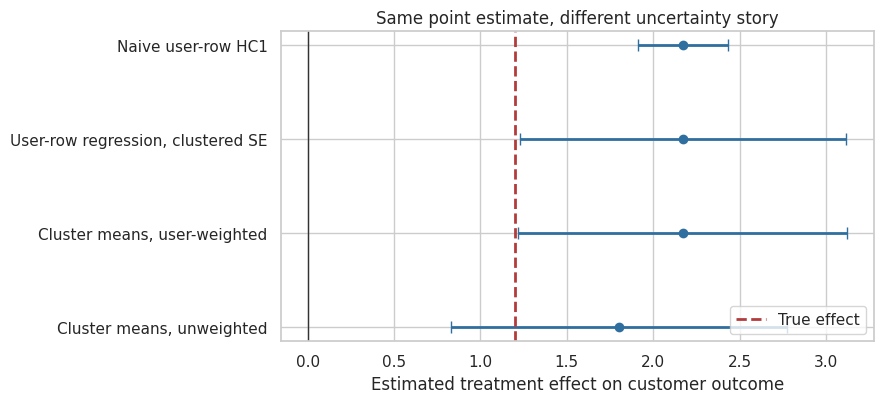

In [10]:
plot_ci_table(
    readout_table,
    title="Same point estimate, different uncertainty story",
    xlabel="Estimated treatment effect on customer outcome",
    reference=1.20,
    figsize=(9, 4.2),
)

The naive user-row analysis usually reports the smallest standard error because it behaves as if every customer row were an independently randomized unit. The cluster-aware analyses recognize that assignment occurred at the store level.

The cluster-robust approach is often convenient because it keeps individual rows and allows individual-level covariates. The cluster-level approach is often useful as a transparent diagnostic because it shows the experiment's independent units directly. In practice, it is common to report a regression with cluster-robust standard errors and also sanity-check the result using cluster-level summaries.

## 6. Adding More Users Inside the Same Clusters Has Diminishing Returns

In an individually randomized experiment, doubling the number of independent users roughly reduces standard errors by a factor of $\sqrt{2}$. In a clustered experiment, adding more users inside the same stores helps, but the benefit slows down when ICC is positive.

For a fixed number of clusters $G$ and equal cluster size $m$:

$$
N = Gm,
$$

and the effective sample size is approximately:

$$
N_{eff} = \frac{Gm}{1 + (m - 1)\rho}.
$$

As $m$ gets large, $N_{eff}$ approaches roughly $G / \rho$. The ceiling is driven by the number of clusters and the ICC.

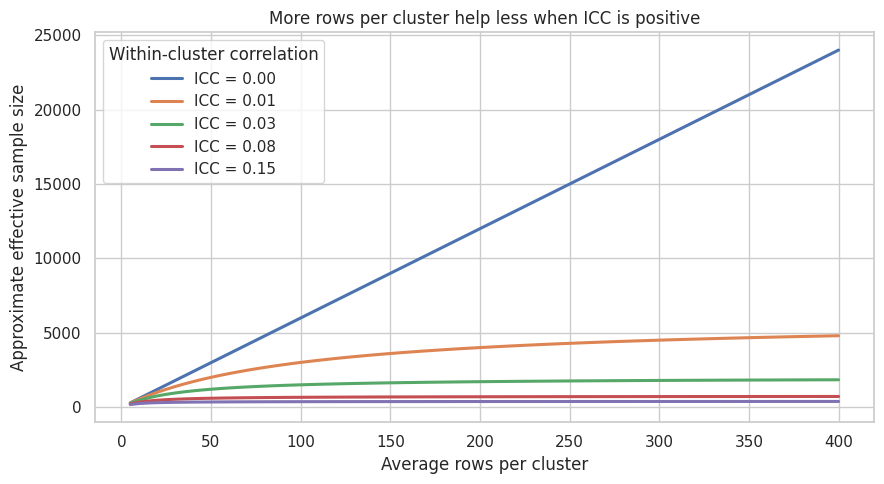

In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
cluster_count = 60
m_grid = np.arange(5, 401, 5)
icc_grid = [0.00, 0.01, 0.03, 0.08, 0.15]
curve_rows = []
for icc in icc_grid:
    for m in m_grid:
        total_n = cluster_count * m
        curve_rows.append({
            "avg_cluster_size": m,
            "icc": icc,
            "total_rows": total_n,
            "effective_n": effective_sample_size(total_n, m, icc),
        })
curve_df = pd.DataFrame(curve_rows)

fig, ax = plt.subplots(figsize=(9, 5))
for icc in icc_grid:
    part = curve_df.query("icc == @icc")
    ax.plot(part["avg_cluster_size"], part["effective_n"], linewidth=2.2, label=f"ICC = {icc:.2f}")
ax.set_title("More rows per cluster help less when ICC is positive")
ax.set_xlabel("Average rows per cluster")
ax.set_ylabel("Approximate effective sample size")
ax.legend(title="Within-cluster correlation")
plt.tight_layout()
plt.show()

When $\rho = 0$, effective sample size grows linearly with rows. When $\rho > 0$, the curves bend. After some point, the better design move is usually to add clusters rather than add more users inside the same clusters.

This is one of the most important design conversations for industry experiments. If a company can choose between 20 stores with many visits and 80 stores with fewer visits each, the second design may be much more informative, even with fewer total rows.

## 7. Few Clusters Can Break Otherwise Reasonable Analyses

Clustered experiments need enough clusters. With very few clusters, standard large-sample approximations can be fragile. Taljaard et al. (2016) focus specifically on risks that arise when cluster-randomized and stepped-wedge designs have only a small number of clusters. Cameron and Miller (2015) also discuss problems with cluster-robust inference when the number of clusters is small.

A simple simulation makes the point. We set the true treatment effect to zero and repeat the experiment many times. A valid 5% test should reject about 5% of the time.

In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def one_null_cluster_trial(n_clusters=20, units_per_cluster=80, icc=0.08, seed=None):
    """Compute one null cluster trial for 05. Clustered Experiments.

    Args:
        n_clusters: Number of randomized or observed clusters.
        units_per_cluster: Number of units generated per cluster.
        icc: Intracluster correlation.
        seed: Random seed used for reproducibility.

    Returns:
        dict: Naive and cluster-aware p-values from one null clustered trial.
    """
    local_rng = np.random.default_rng(seed)
    cluster_ids = np.arange(n_clusters)
    treated_clusters = local_rng.choice(cluster_ids, size=n_clusters // 2, replace=False)
    z_cluster = np.isin(cluster_ids, treated_clusters).astype(int)

    unit_sd = 4.0
    sigma_cluster = np.sqrt(icc / (1 - icc)) * unit_sd
    cluster_effect = local_rng.normal(0, sigma_cluster, size=n_clusters)

    rows = []
    for cluster_id, z, u in zip(cluster_ids, z_cluster, cluster_effect):
        y = 50 + u + local_rng.normal(0, unit_sd, size=units_per_cluster)
        rows.append(pd.DataFrame({"cluster_id": cluster_id, "treatment": z, "outcome": y}))
    df = pd.concat(rows, ignore_index=True)

    naive_p = stats.ttest_ind(
        df.loc[df["treatment"] == 1, "outcome"],
        df.loc[df["treatment"] == 0, "outcome"],
        equal_var=False,
    ).pvalue

    cluster_means = df.groupby(["cluster_id", "treatment"], as_index=False)["outcome"].mean()
    cluster_p = stats.ttest_ind(
        cluster_means.loc[cluster_means["treatment"] == 1, "outcome"],
        cluster_means.loc[cluster_means["treatment"] == 0, "outcome"],
        equal_var=False,
    ).pvalue
    return naive_p, cluster_p

sim_rows = []
for n_clusters in [8, 12, 20, 60]:
    for sim in range(800):
        naive_p, cluster_p = one_null_cluster_trial(
            n_clusters=n_clusters,
            units_per_cluster=80,
            icc=0.08,
            seed=10_000 * n_clusters + sim,
        )
        sim_rows.append({
            "clusters": n_clusters,
            "method": "Naive user-row t-test",
            "reject": naive_p < 0.05,
        })
        sim_rows.append({
            "clusters": n_clusters,
            "method": "Cluster-level t-test",
            "reject": cluster_p < 0.05,
        })

false_positive_df = pd.DataFrame(sim_rows)
false_positive_summary = (
    false_positive_df.groupby(["clusters", "method"], as_index=False)["reject"]
    .mean()
    .rename(columns={"reject": "false_positive_rate"})
)
false_positive_summary.pivot(index="clusters", columns="method", values="false_positive_rate").round(3)

method,Cluster-level t-test,Naive user-row t-test
clusters,,
8,0.048,0.464
12,0.059,0.472
20,0.049,0.501
60,0.058,0.486


In Few Clusters Can Break Otherwise Reasonable Analyses, the table links the statistical evidence to the launch decision. The primary metric says what improved; guardrails and multiplicity checks keep that evidence honest.

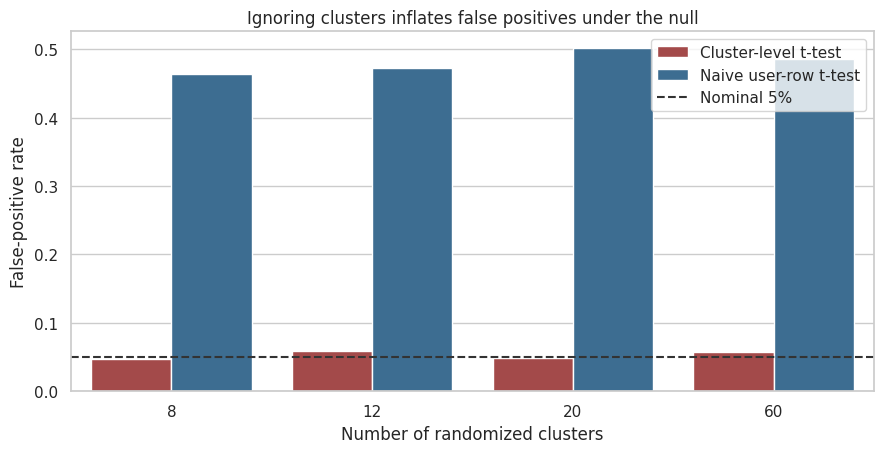

In [13]:
# Build the Few Clusters Can Break Otherwise Reasonable Analyses plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.7))
sns.barplot(
    data=false_positive_summary,
    x="clusters",
    y="false_positive_rate",
    hue="method",
    palette=["#b23b3b", "#2f6f9f"],
    ax=ax,
)
ax.axhline(0.05, color="#333333", linestyle="--", linewidth=1.5, label="Nominal 5%")
ax.set_title("Ignoring clusters inflates false positives under the null")
ax.set_xlabel("Number of randomized clusters")
ax.set_ylabel("False-positive rate")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The naive test over-rejects because it counts many correlated user rows as if they were independent. The cluster-level test is imperfect in some small-sample settings, yet it is much closer to the design. The main lesson is that the effective evidence comes from independently randomized clusters.

When the number of clusters is small, analysts often need small-sample corrections, randomization inference, permutation tests at the cluster level, or wild cluster bootstrap methods. The exact choice depends on the design and the inferential target.

## 8. Unequal Cluster Sizes Change the Estimand Conversation

Clustered experiments often have unequal cluster sizes. One region may have many more users than another. One enterprise account may have many more seats than another. One store may have much more traffic than another.

This creates an estimand question:

| Estimand | Informal meaning | Weighting |
|---|---|---|
| Cluster-weighted effect | Effect for the average cluster | Each cluster gets equal weight |
| User-weighted effect | Effect for the average user or visit | Larger clusters get more weight |

Neither estimand is automatically right. A marketplace may care about the average transaction, while an operations team may care about the average site. The problem is failing to say which one is being estimated.

In [14]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_unequal_cluster_estimands(seed=20260429):
    """Generate a clustered experiment where unequal cluster sizes change estimand interpretation.

    Args:
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    local_rng = np.random.default_rng(seed)
    n_clusters = 70
    cluster_ids = np.arange(n_clusters)
    sizes = np.round(local_rng.lognormal(mean=np.log(120), sigma=0.85, size=n_clusters)).astype(int)
    sizes = np.clip(sizes, 20, 700)
    log_size_z = (np.log(sizes) - np.log(sizes).mean()) / np.log(sizes).std()
    tau_cluster = 0.90 + 0.35 * log_size_z
    baseline_cluster = local_rng.normal(0, 2.5, size=n_clusters)

    treated_clusters = local_rng.choice(cluster_ids, size=n_clusters // 2, replace=False)
    z_cluster = np.isin(cluster_ids, treated_clusters).astype(int)

    rows = []
    potential_cluster = []
    for cluster_id, n, z, tau, base in zip(cluster_ids, sizes, z_cluster, tau_cluster, baseline_cluster):
        x = local_rng.normal(0, 1, size=n)
        y0 = 40 + base + 2.0 * x + local_rng.normal(0, 4.0, size=n)
        y1 = y0 + tau
        y = np.where(z == 1, y1, y0)
        rows.append(pd.DataFrame({
            "cluster_id": cluster_id,
            "treatment": z,
            "outcome": y,
            "cluster_size": n,
            "true_cluster_effect": tau,
        }))
        potential_cluster.append({
            "cluster_id": cluster_id,
            "cluster_size": n,
            "true_cluster_effect": tau,
            "treatment": z,
        })
    return pd.concat(rows, ignore_index=True), pd.DataFrame(potential_cluster)


df_unequal, cluster_truth = simulate_unequal_cluster_estimands()
cluster_observed = df_unequal.groupby(["cluster_id", "treatment"], as_index=False).agg(
    outcome=("outcome", "mean"),
    cluster_size=("outcome", "size"),
    true_cluster_effect=("true_cluster_effect", "first"),
)

true_cluster_weighted = cluster_truth["true_cluster_effect"].mean()
true_user_weighted = np.average(cluster_truth["true_cluster_effect"], weights=cluster_truth["cluster_size"])
observed_cluster_weighted = (
    cluster_observed.query("treatment == 1")["outcome"].mean()
    - cluster_observed.query("treatment == 0")["outcome"].mean()
)
observed_user_weighted = (
    df_unequal.query("treatment == 1")["outcome"].mean()
    - df_unequal.query("treatment == 0")["outcome"].mean()
)

estimand_table = pd.DataFrame({
    "quantity": [
        "True cluster-weighted ATE",
        "True user-weighted ATE",
        "Observed cluster-weighted difference",
        "Observed user-weighted difference",
    ],
    "value": [true_cluster_weighted, true_user_weighted, observed_cluster_weighted, observed_user_weighted],
})
estimand_table.round(3)

,quantity,value
0,True cluster-weighted ATE,0.900
1,True user-weighted ATE,1.148
2,Observed cluster-weighted difference,0.561
3,Observed user-weighted difference,0.927


In Unequal Cluster Sizes Change the Estimand Conversation, the table shows how much independent information the design really contains. With clustered data, row counts can exaggerate precision unless uncertainty follows the randomization unit.

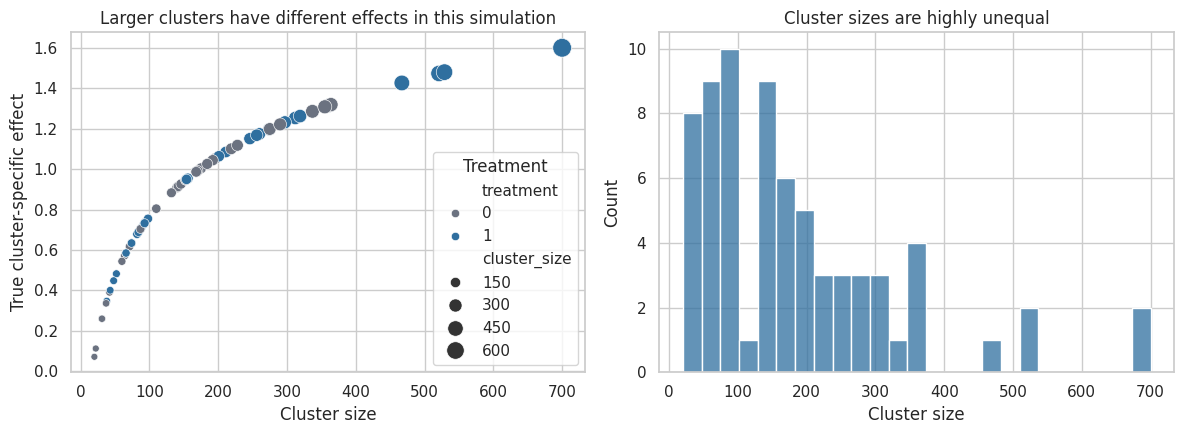

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(
    data=cluster_truth,
    x="cluster_size",
    y="true_cluster_effect",
    hue="treatment",
    size="cluster_size",
    sizes=(25, 180),
    palette={0: "#6b7280", 1: "#2f6f9f"},
    ax=axes[0],
)
axes[0].set_title("Larger clusters have different effects in this simulation")
axes[0].set_xlabel("Cluster size")
axes[0].set_ylabel("True cluster-specific effect")
axes[0].legend(title="Treatment", loc="best")

sns.histplot(data=cluster_truth, x="cluster_size", bins=25, color="#2f6f9f", ax=axes[1])
axes[1].set_title("Cluster sizes are highly unequal")
axes[1].set_xlabel("Cluster size")
plt.tight_layout()
plt.show()

The true user-weighted and cluster-weighted effects differ because larger clusters have different treatment effects. That may happen in real business settings: large enterprise accounts may respond differently from small accounts, high-volume stores may respond differently from low-volume stores, and dense cities may respond differently from rural markets.

This is not a nuisance detail. It is a product question. If the decision is about total customer impact, user-weighted may be appropriate. If the decision is about whether the intervention works for a typical site, cluster-weighted may be appropriate. The analysis should match the decision.

## 9. Blocking and Pair Matching at the Cluster Level

Cluster randomization can produce imbalance when there are not many clusters. A simple improvement is to block or pair clusters using pre-treatment information, then randomize within each block or pair.

For example:

- Pair stores with similar pre-period sales, then randomize one store in each pair.
- Stratify regions by size and geography, then randomize within strata.
- Pair enterprise accounts by industry, contract size, and baseline usage.

Imai, King, and Nall (2009) argue that pair matching can recover efficiency in cluster-randomized experiments when feasible. The basic business intuition is simple: compare treated and control clusters that looked similar before treatment.

In [16]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def assign_complete_randomization(clusters, seed=None):
    """Assign clusters by complete randomization for a design-comparison exercise.

    Args:
        clusters: Cluster-level DataFrame used for assignment or balance calculations.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame or numpy.ndarray: Copy of the data with the requested assignment or derived variables added.
    """
    local_rng = np.random.default_rng(seed)
    n = len(clusters)
    treated = local_rng.choice(clusters.index.to_numpy(), size=n // 2, replace=False)
    z = pd.Series(0, index=clusters.index)
    z.loc[treated] = 1
    return z


def assign_pair_matched(clusters, match_col, seed=None):
    """Assign clusters within matched pairs to improve balance.

    Args:
        clusters: Cluster-level DataFrame used for assignment or balance calculations.
        match_col: Cluster-level covariate used to form matched assignment pairs.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame or numpy.ndarray: Copy of the data with the requested assignment or derived variables added.
    """
    local_rng = np.random.default_rng(seed)
    ordered = clusters.sort_values(match_col).copy()
    z = pd.Series(0, index=clusters.index)
    for start in range(0, len(ordered) - 1, 2):
        pair_idx = ordered.index[start:start + 2].to_numpy()
        treated_idx = local_rng.choice(pair_idx, size=1)[0]
        z.loc[treated_idx] = 1
    if len(ordered) % 2 == 1:
        z.loc[ordered.index[-1]] = local_rng.integers(0, 2)
    return z


def standardized_difference(x, z):
    """Compute a standardized difference for one covariate under assignment.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        z: Assignment or instrument vector used to define comparison groups.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    treated = x[z == 1]
    control = x[z == 0]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    return (treated.mean() - control.mean()) / pooled_sd

local_rng = np.random.default_rng(20260430)
cluster_plan = pd.DataFrame({
    "cluster_id": np.arange(50),
    "pre_period_sales": local_rng.lognormal(mean=10.2, sigma=0.55, size=50),
})

balance_rows = []
for sim in range(1500):
    z_complete = assign_complete_randomization(cluster_plan, seed=sim)
    z_pair = assign_pair_matched(cluster_plan, "pre_period_sales", seed=sim)
    balance_rows.append({
        "method": "Complete randomization",
        "abs_standardized_difference": abs(standardized_difference(cluster_plan["pre_period_sales"], z_complete)),
    })
    balance_rows.append({
        "method": "Pair-matched randomization",
        "abs_standardized_difference": abs(standardized_difference(cluster_plan["pre_period_sales"], z_pair)),
    })

balance_df = pd.DataFrame(balance_rows)
balance_df.groupby("method")["abs_standardized_difference"].describe(percentiles=[0.5, 0.8, 0.9, 0.95]).round(3)

,count,mean,std,min,50%,80%,90%,95%,max
method,,,,,,,,,
Complete randomization,1500.0,0.230,0.168,0.0,0.198,0.369,0.457,0.554,0.975
Pair-matched randomization,1500.0,0.052,0.035,0.0,0.049,0.088,0.095,0.101,0.123


In Blocking and Pair Matching at the Cluster Level, the table is a design check. Outcome interpretation comes after the assignment table looks consistent with the design.

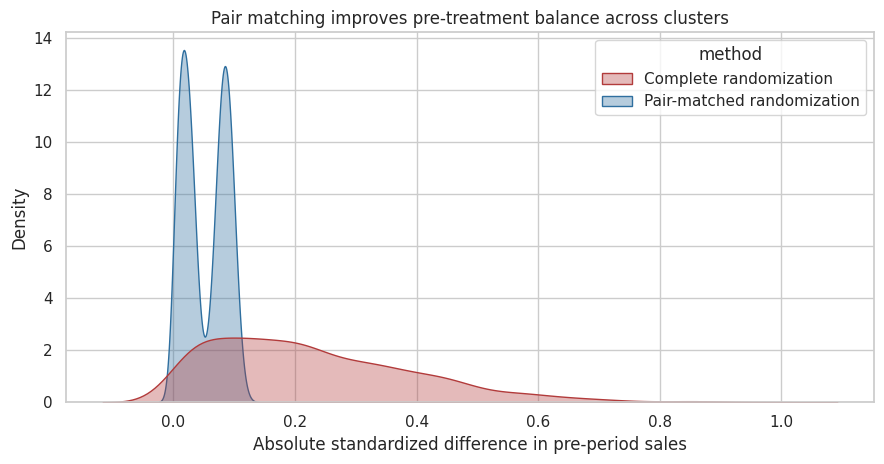

In [17]:
# Build the Blocking and Pair Matching at the Cluster Level plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.kdeplot(
    data=balance_df,
    x="abs_standardized_difference",
    hue="method",
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette=["#b23b3b", "#2f6f9f"],
    ax=ax,
)
ax.set_title("Pair matching improves pre-treatment balance across clusters")
ax.set_xlabel("Absolute standardized difference in pre-period sales")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

Pair matching sharply reduces the chance that treated clusters have much higher or lower pre-period sales than control clusters. This does not guarantee perfect precision, and the analysis should respect the matched design, but it is often a major improvement when clusters are scarce and heterogeneous.

For industry experiments, matching variables should be chosen before randomization and should be pre-treatment variables: baseline volume, geography, business segment, historical outcome level, device class, or platform role.

## 10. Choosing an Analysis Strategy

There is no single analysis rule for every clustered experiment. A useful workflow is:

| Situation | Reasonable starting point |
|---|---|
| Many clusters, individual-level covariates matter | Individual-level regression with cluster-robust standard errors |
| Few clusters | Cluster-level analysis, randomization inference, or small-sample methods |
| Matched or blocked design | Include block indicators or analyze within matched pairs |
| Unequal cluster sizes | State cluster-weighted vs user-weighted estimand before analysis |
| Strong baseline predictors | Adjust for pre-treatment cluster-level or unit-level covariates |
| Spillovers across clusters | Reconsider cluster definition; may need network/interference design |
| Treatment delivered at cluster level but outcome at user level | Keep user-level metric definition, cluster-aware inference |

A good analysis plan says what the randomization unit is, what the estimand is, and how uncertainty will be computed. It should be written before outcomes are inspected.

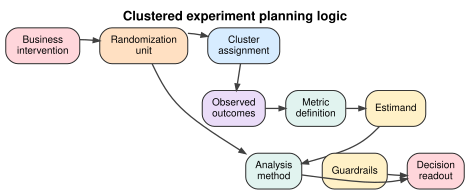

In [18]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_clustered_planning_workflow(analysis_colors):
    """
    Draw the planning workflow for clustered experiments.
    
    Idea:
        The workflow connects business units, randomization level, ICC, design effect, and analysis choice.
    
    Args:
        analysis_colors: Color palette used for clustered-experiment planning nodes.
    
    Returns:
        graphviz.Digraph: Curved workflow diagram ready for notebook display.
    """

    dot = Digraph(format="svg")
    dot.attr(
        bgcolor="transparent",
        pad="0.08",
        ranksep="0.38",
        nodesep="0.28",
        splines="curved",
        size="7,4",
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2b2b2b",
        fontname="Helvetica",
        fontsize="10",
        margin="0.10,0.06",
    )
    dot.attr("edge", color="#404040", arrowsize="0.65", penwidth="1.3")
    dot.attr(
        label="Clustered experiment planning logic",
        labelloc="t",
        fontsize="13",
        fontname="Helvetica-Bold",
    )

    labels = {
        "intervention": "Business\nintervention",
        "unit": "Randomization\nunit",
        "assignment": "Cluster\nassignment",
        "outcomes": "Observed\noutcomes",
        "metric": "Metric\ndefinition",
        "estimand": "Estimand",
        "guardrails": "Guardrails",
        "method": "Analysis\nmethod",
        "readout": "Decision\nreadout",
    }
    colors = {
        "intervention": analysis_colors["Business intervention"],
        "unit": analysis_colors["Randomization unit"],
        "assignment": analysis_colors["Cluster assignment"],
        "outcomes": analysis_colors["Observed outcomes"],
        "metric": analysis_colors["Metric definition"],
        "estimand": analysis_colors["Estimand"],
        "guardrails": analysis_colors["Guardrails"],
        "method": analysis_colors["Analysis method"],
        "readout": analysis_colors["Decision readout"],
    }

    for node, label in labels.items():
        dot.node(node, label=label, fillcolor=colors[node])

    for row in [
        ("intervention", "unit", "assignment"),
        ("outcomes", "metric", "estimand"),
        ("guardrails", "method", "readout"),
    ]:
        with dot.subgraph() as rank:
            rank.attr(rank="same")
            for node in row:
                rank.node(node)

    workflow_edges = [
        ("intervention", "unit"),
        ("unit", "assignment"),
        ("assignment", "outcomes"),
        ("outcomes", "metric"),
        ("metric", "estimand"),
        ("estimand", "method"),
        ("unit", "method"),
        ("guardrails", "readout"),
        ("method", "readout"),
    ]
    for source, target in workflow_edges:
        dot.edge(source, target)
    return dot


analysis_colors = {
    "Business intervention": COLORS["decision"],
    "Randomization unit": COLORS["cluster"],
    "Cluster assignment": COLORS["assignment"],
    "Observed outcomes": COLORS["outcome"],
    "Metric definition": COLORS["analysis"],
    "Estimand": COLORS["warning"],
    "Analysis method": COLORS["analysis"],
    "Decision readout": COLORS["decision"],
    "Guardrails": COLORS["warning"],
}

smart_display(make_clustered_planning_workflow(analysis_colors))

In Choosing an Analysis Strategy, use the figure as a quick design check. Surprising assignment patterns or baseline balance should be investigated before outcomes.

## 11. A Clustered Experiment Planning Card

Here is a compact planning card for the retail example.

| field | example |
|---|---|
| Decision | Roll out merchandising policy to all stores? |
| Intervention | Store-level merchandising and staff checklist |
| Randomization unit | Store |
| Observation unit | Customer visit |
| Primary estimand | User-weighted effect on customer value per visit |
| Primary metric | Experiment-period customer value |
| Expected ICC | Use historical store data to estimate ICC before launch |
| Cluster count | 80 stores, 40 treatment and 40 control |
| Average cluster size | About 90 eligible visits per store |
| Analysis plan | User-level regression with store-clustered SE; cluster-mean sensitivity check |
| Balance plan | Pair stores by pre-period sales before randomization if feasible |
| Guardrails | Refunds, stockouts, support contacts, checkout latency |
| Main risk | Too few stores or large store-size imbalance |


## 12. Key Takeaways

- Clustered experiments randomize groups, not individual rows.
- The unit of randomization drives the independence structure of the evidence.
- Positive ICC means rows inside the same cluster provide partially redundant information.
- The design effect, $1 + (m - 1)\rho$, explains why large clustered datasets can have much smaller effective sample sizes.
- Naive user-level standard errors are often too small when treatment is assigned at the cluster level.
- Cluster-robust standard errors and cluster-level analyses are two useful ways to respect the design.
- Few clusters require special care; large-sample cluster-robust approximations may be fragile.
- Unequal cluster sizes force an estimand choice: average cluster or average user.
- Blocking and pair matching can improve balance and precision when clusters are scarce.
- A professional experiment plan names the randomization unit, estimand, ICC assumptions, analysis method, and guardrails before launch.

The next notebook will focus on noncompliance, intent-to-treat, and treatment-on-treated: what happens when assignment and actual treatment receipt differ.

## 13. Real-Data Companion: Grunfeld Firm Panel and Clustered Dependence

The clustered-experiment simulation gives us a known treatment effect and a known intraclass correlation. Real grouped data rarely give us that comfort. The Grunfeld investment panel gives a compact real example of repeated observations inside firms.

This companion is not a randomized experiment. It is a dependence check. We use firm-year data to show why treating repeated rows as independent can make uncertainty look too small. The unit in the table is a firm-year, but the independent information is partly at the firm level because observations from the same firm share history, scale, management, industry position, and accounting conventions.

Data source: [statsmodels Grunfeld dataset](https://www.statsmodels.org/stable/datasets/generated/grunfeld.html).

**How to read this real-data section.** Use the data to stress-test the diagnostics. Real covariates and real measurement make the exercise useful, but identification still comes from the design rather than the method name.


**Real-data dataset note.** The Grunfeld data are a firm-year panel, not a randomized clustered experiment. We use them to rehearse the dependence problem that clustered experiments create. The units are firms observed over years, and repeated observations from the same firm are correlated because firms have persistent scale, investment strategy, and market conditions. This companion is not making a causal claim about an intervention. It shows why clustered or panel data need standard errors and summaries that respect the grouping structure before a field experiment or quasi-experiment is interpreted.

,firm,years,mean_investment,mean_market_value,mean_capital
0,General Motors,20,608.02,4333.84,648.44
1,US Steel,20,410.48,1971.82,294.86
2,General Electric,20,102.29,1941.32,400.16
3,Chrysler,20,86.12,693.21,121.24
4,Atlantic Refining,20,61.80,231.47,486.76
5,IBM,20,55.41,419.86,104.28
6,Union Oil,20,47.60,149.79,314.94
7,Westinghouse,20,42.89,670.91,85.64


,term,estimate,HC1_se_treating_rows_as_independent,clustered_by_firm_se,clustered_to_HC1_ratio
0,value,0.114500,0.006800,0.016200,2.390100
1,capital,0.227500,0.048900,0.085500,1.748100


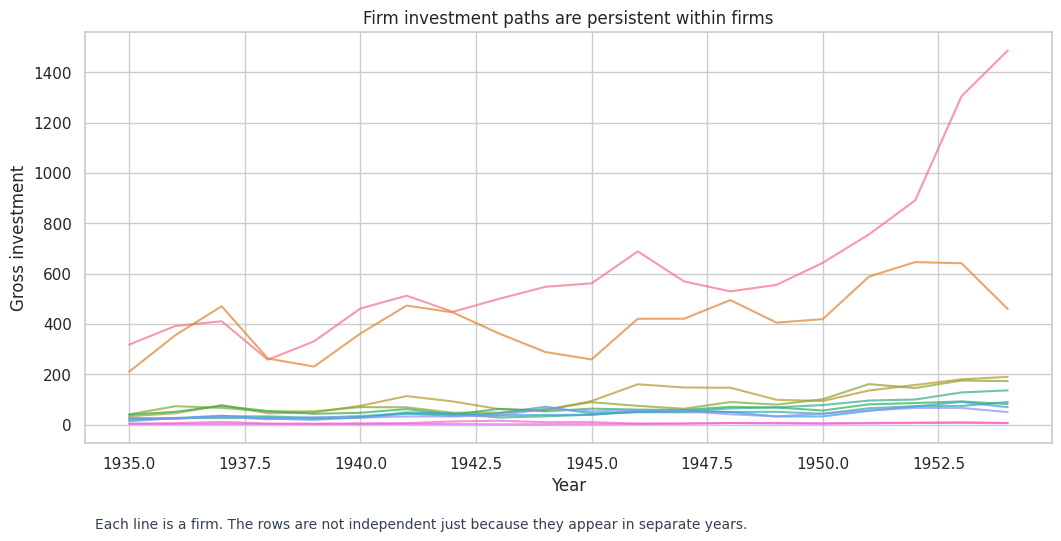

In [19]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_statsmodels_grunfeld, optional_data_note

RUN_REAL_DATA_COMPANION = True
GRUNFELD_SOURCE = "https://www.statsmodels.org/stable/datasets/generated/grunfeld.html"

if RUN_REAL_DATA_COMPANION:
    grunfeld = load_statsmodels_grunfeld().copy()
    grunfeld["year"] = grunfeld["year"].astype(int)

    firm_summary = (
        grunfeld.groupby("firm")
        .agg(
            years=("year", "nunique"),
            mean_investment=("invest", "mean"),
            mean_market_value=("value", "mean"),
            mean_capital=("capital", "mean"),
        )
        .sort_values("mean_investment", ascending=False)
        .reset_index()
    )
    smart_display(firm_summary.head(8).round(2))

    naive_panel_model = smf.ols("invest ~ value + capital", data=grunfeld).fit(cov_type="HC1")
    clustered_panel_model = smf.ols("invest ~ value + capital", data=grunfeld).fit(
        cov_type="cluster",
        cov_kwds={"groups": grunfeld["firm"]},
    )

    cluster_se_table = pd.DataFrame(
        [
            {
                "term": term,
                "estimate": clustered_panel_model.params[term],
                "HC1_se_treating_rows_as_independent": naive_panel_model.bse[term],
                "clustered_by_firm_se": clustered_panel_model.bse[term],
            }
            for term in ["value", "capital"]
        ]
    )
    cluster_se_table["clustered_to_HC1_ratio"] = (
        cluster_se_table["clustered_by_firm_se"] / cluster_se_table["HC1_se_treating_rows_as_independent"]
    )
    smart_display(cluster_se_table.round(4))

    fig, ax = plt.subplots(figsize=(10.5, 5.3), constrained_layout=True)
    sns.lineplot(data=grunfeld, x="year", y="invest", hue="firm", legend=False, alpha=0.72, ax=ax)
    ax.set_title("Firm investment paths are persistent within firms")
    ax.set_xlabel("Year")
    ax.set_ylabel("Gross investment")
    note = "Each line is a firm. The rows are not independent just because they appear in separate years."
    ax.text(0.01, -0.18, note, transform=ax.transAxes, ha="left", va="top", fontsize=10, color="#334155")
    plt.show()
else:
    optional_data_note("Grunfeld firm investment panel", GRUNFELD_SOURCE, "RUN_REAL_DATA_COMPANION")

The real panel makes the clustered-experiment lesson more concrete. Standard errors change, and the deeper issue is that the unit of analysis has to match the way independent information enters the design.

In an actual clustered experiment, the randomization unit would determine the primary analysis. In a firm panel like this one, clustering by firm is a minimum realism check because investment observations from the same firm are tied together over time.

## References

Campbell, M. K., Elbourne, D. R., & Altman, D. G. (2004). CONSORT statement: Extension to cluster randomised trials. *BMJ, 328*(7441), 702-708. https://doi.org/10.1136/bmj.328.7441.702

Cameron, A. C., & Miller, D. L. (2015). A practitioner's guide to cluster-robust inference. *Journal of Human Resources, 50*(2), 317-372. https://doi.org/10.3368/jhr.50.2.317

Desai, M., Bryson, S. W., & Robinson, T. N. (2013). On the use of robust estimators for standard errors in the presence of clustering when clustering membership is misspecified. *Contemporary Clinical Trials, 34*(2), 248-256. https://doi.org/10.1016/j.cct.2012.11.006

Handlos, L. N., Chakraborty, H., Sen, P. K., & Sammel, M. D. (2009). Evaluation of cluster-randomized trials on maternal and child health research in developing countries. *Tropical Medicine & International Health, 14*(8), 947-956. https://doi.org/10.1111/j.1365-3156.2009.02313.x

Imai, K., King, G., & Nall, C. (2009). The essential role of pair matching in cluster-randomized experiments, with application to the Mexican Universal Health Insurance Evaluation. *Statistical Science, 24*(1), 29-53. https://doi.org/10.1214/08-sts274

Kennedy-Shaffer, L., & Hughes, M. D. (2021). Power and sample size calculations for cluster randomized trials with binary outcomes when intracluster correlation coefficients vary by treatment arm. *Clinical Trials, 19*(1), 42-51. https://doi.org/10.1177/17407745211059845

Peerawaranun, P., Landier, J., Nosten, F. H., & Chaumeau, V. (2019). Intracluster correlation coefficients in the Greater Mekong Subregion for sample size calculations of cluster randomized malaria trials. *Malaria Journal, 18*, 428. https://doi.org/10.1186/s12936-019-3062-x

Taljaard, M., Teerenstra, S., Ivers, N., & Fergusson, D. A. (2016). Substantial risks associated with few clusters in cluster randomized and stepped wedge designs. *Clinical Trials, 13*(4), 459-463. https://doi.org/10.1177/1740774516634316